# Collections Recovery Analysis — Simple & Business-Focused

### Goal
Leadership has been told that **recovery improved by 11% month-on-month**. This notebook checks whether that statement is reliable.

I use only **pandas, NumPy and Matplotlib**. The analysis is intentionally simple: first clean the key data, then compare recovery using fair denominators, check whether the improvement came from better operations or a different mix of accounts, and finally give a practical investment recommendation.

> **Main rule:** do not trust a percentage until both the numerator and denominator are clear.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Change this path only if your CSV folder is stored somewhere else.
DATA_DIR = '../data'

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Libraries loaded: pandas, numpy, matplotlib')

Libraries loaded: pandas, numpy, matplotlib


## 1. Load only the tables needed for the main business questions

The assignment contains many files, but a clear analysis does not need to join everything at once. For the core recovery story I use:

- **accounts** → account balance, DPD, risk segment and loan type
- **payments** → actual money recovered
- **daily_targeting** → which accounts were selected for collection
- **calls** → contact activity
- **campaigns** → campaign dates and strategy versions
- **agents / borrowers** → data-quality checks

Other raw files can still be used later for deeper forensic checks.

In [2]:
accounts = pd.read_csv(f'{DATA_DIR}/accounts.csv')
payments_raw = pd.read_csv(f'{DATA_DIR}/payments.csv')
targeting = pd.read_csv(f'{DATA_DIR}/daily_targeting.csv')
calls_raw = pd.read_csv(f'{DATA_DIR}/calls.csv')
campaigns = pd.read_csv(f'{DATA_DIR}/campaigns.csv')
agents = pd.read_csv(f'{DATA_DIR}/agents.csv')
borrowers = pd.read_csv(f'{DATA_DIR}/borrowers.csv')

summary = pd.DataFrame({
    'table': ['accounts','payments','daily_targeting','calls','campaigns','agents','borrowers'],
    'rows': [len(accounts),len(payments_raw),len(targeting),len(calls_raw),len(campaigns),len(agents),len(borrowers)]
})
summary

,table,rows
0,accounts,30000
1,payments,25500
2,daily_targeting,45000
3,calls,91350
4,campaigns,120
5,agents,30000
6,borrowers,30600


## 2. Build a small trusted analytical layer

I keep the cleaning rules easy to explain:

1. **Account ID is the main account key.**
2. **One payment ID = one payment event.** Duplicate payment IDs are removed before calculating recovery.
3. Only **SUCCESS** payments count as recovered money.
4. August is treated as **partial month** because the data ends on August 8.
5. Monthly targeting is reduced to one row per **month × account**, so repeatedly targeting the same account does not inflate the denominator.

In [3]:
# ---------- Accounts ----------
accounts_clean = accounts.drop_duplicates(subset='account_id', keep='first').copy()

# ---------- Payments ----------
payments = payments_raw.copy()
payments['event_at'] = pd.to_datetime(payments['event_at'])

payment_duplicates = payments.duplicated(subset='payment_id').sum()
payments = payments.sort_values('event_at').drop_duplicates(subset='payment_id', keep='first')

payments['month'] = payments['event_at'].dt.to_period('M').dt.to_timestamp()
payments['is_recovered'] = payments['payment_status'].eq('SUCCESS')

# ---------- Targeting ----------
targeting['target_date'] = pd.to_datetime(targeting['target_date'])
targeting['month'] = targeting['target_date'].dt.to_period('M').dt.to_timestamp()
monthly_targets = targeting[['month','account_id']].drop_duplicates()

# ---------- Calls ----------
calls = calls_raw.drop_duplicates().copy()
calls['event_at'] = pd.to_datetime(calls['event_at'])
calls['month'] = calls['event_at'].dt.to_period('M').dt.to_timestamp()
calls['is_answered'] = calls['call_status'].eq('ANSWERED')

print(f'Duplicate payment IDs removed: {payment_duplicates:,}')
print(f'Clean payment rows: {len(payments):,}')
print(f'Unique accounts in account master: {accounts_clean.account_id.nunique():,}')

Duplicate payment IDs removed: 500
Clean payment rows: 25,000
Unique accounts in account master: 30,000


### What this means
The payment file has repeated transaction IDs, so summing the raw file would slightly overstate recovery. The cleaned payment table is therefore the safer numerator for all recovery calculations.

## 3. Quick data-quality checks

Before analyzing performance, I check whether some IDs can be trusted across tables. This matters because a dashboard can look correct even when joins are wrong.

In [4]:
# Duplicate / conflicting master records
agent_rows = len(agents)
unique_agents = agents['agent_id'].nunique()
borrower_rows = len(borrowers)
unique_borrowers = borrowers['borrower_id'].nunique()

# Compare borrower_id carried in payments/calls with the borrower_id in the account master
account_borrower = accounts_clean[['account_id','borrower_id']].rename(columns={'borrower_id':'master_borrower_id'})

pay_check = payments_raw[['account_id','borrower_id']].merge(account_borrower, on='account_id', how='left')
call_check = calls_raw[['account_id','borrower_id']].merge(account_borrower, on='account_id', how='left')

pay_mismatch = (pay_check['borrower_id'] != pay_check['master_borrower_id']).mean() * 100
call_mismatch = (call_check['borrower_id'] != call_check['master_borrower_id']).mean() * 100

quality = pd.DataFrame({
    'check': [
        'Duplicate payment IDs',
        'Agent rows vs unique agent IDs',
        'Borrower rows vs unique borrower IDs',
        'Payment borrower ID mismatch vs account master',
        'Call borrower ID mismatch vs account master'
    ],
    'result': [
        f'{payment_duplicates:,} duplicate IDs',
        f'{agent_rows:,} rows / {unique_agents:,} unique IDs',
        f'{borrower_rows:,} rows / {unique_borrowers:,} unique IDs',
        f'{pay_mismatch:.1f}%',
        f'{call_mismatch:.1f}%'
    ]
})
quality

,check,result
0,Duplicate payment IDs,500 duplicate IDs
1,Agent rows vs unique agent IDs,"30,000 rows / 1,000 unique IDs"
2,Borrower rows vs unique borrower IDs,"30,600 rows / 11,015 unique IDs"
3,Payment borrower ID mismatch vs account master,100.0%
4,Call borrower ID mismatch vs account master,100.0%


### Simple takeaway
There are real data-quality issues. In particular, the `borrower_id` stored inside event tables frequently disagrees with the account master. For account-level analysis, I therefore trust **`account_id` first** and use the account table to recover borrower attributes when needed.

This prevents a bad borrower join from creating false geography or customer-segment conclusions.

## 4. Reproduce the reported 11% number

First, I calculate monthly successful recovery after payment-ID deduplication. This tells us where an 11% month-on-month number can appear.

In [5]:
recovered = payments[payments['is_recovered']].copy()

monthly_recovery = (
    recovered.groupby('month', as_index=False)['amount']
    .sum()
    .rename(columns={'amount':'recovery'})
    .sort_values('month')
)
monthly_recovery['mom_change_pct'] = monthly_recovery['recovery'].pct_change() * 100
monthly_recovery['month_name'] = monthly_recovery['month'].dt.strftime('%b')

show = monthly_recovery.copy()
show['recovery_cr'] = show['recovery'] / 1e7
show[['month_name','recovery_cr','mom_change_pct']]

,month_name,recovery_cr,mom_change_pct
0,Jan,18.72,NaN
1,Feb,17.01,-9.13
2,Mar,18.89,11.03
3,Apr,17.51,-7.29
4,May,18.43,5.20
5,Jun,17.56,-4.72
6,Jul,18.72,6.65
7,Aug,4.71,-74.84


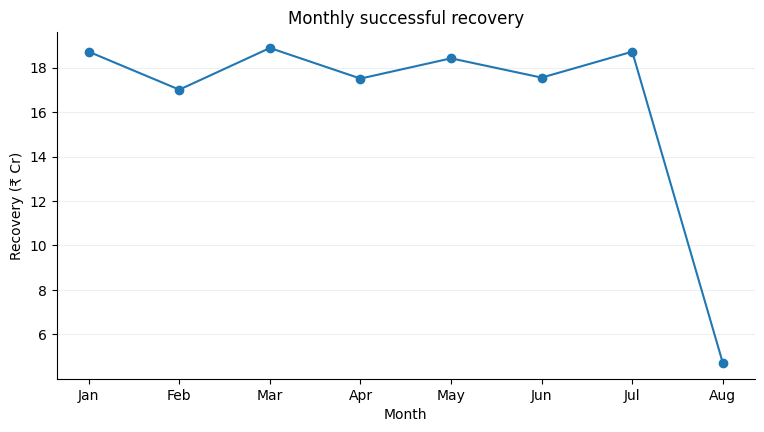

In [6]:
plt.figure(figsize=(9,4.5))
plt.plot(monthly_recovery['month_name'], monthly_recovery['recovery']/1e7, marker='o')
plt.title('Monthly successful recovery')
plt.xlabel('Month')
plt.ylabel('Recovery (₹ Cr)')
plt.grid(axis='y', alpha=0.2)
plt.show()

### What we see
The **February → March** raw monthly total rises by about **11%**. So the business claim can be reproduced from the raw monthly total.

But this is not enough to prove that collection performance improved. March has more calendar days than February, and different months may also contain different account mixes.

## 5. Make the month comparison fair: recovery per day

February has 28 days and March has 31. If daily performance stayed almost the same, March would naturally collect more money simply because it has three extra days.

In [7]:
monthly_recovery['days_in_period'] = monthly_recovery['month'].dt.days_in_month

# August contains data only through Aug 8, so do not divide it by 31.
monthly_recovery.loc[monthly_recovery['month'].eq(pd.Timestamp('2026-08-01')), 'days_in_period'] = 8

monthly_recovery['recovery_per_day'] = monthly_recovery['recovery'] / monthly_recovery['days_in_period']
monthly_recovery['daily_mom_change_pct'] = monthly_recovery['recovery_per_day'].pct_change() * 100

monthly_recovery[['month_name','days_in_period','recovery','mom_change_pct','recovery_per_day','daily_mom_change_pct']]

,month_name,days_in_period,recovery,mom_change_pct,recovery_per_day,daily_mom_change_pct
0,Jan,31,"187,229,127.59",NaN,"6,039,649.28",NaN
1,Feb,28,"170,142,453.76",-9.13,"6,076,516.21",0.61
2,Mar,31,"188,912,374.02",11.03,"6,093,947.55",0.29
3,Apr,30,"175,138,043.41",-7.29,"5,837,934.78",-4.20
4,May,31,"184,250,278.50",5.20,"5,943,557.37",1.81
5,Jun,30,"175,559,726.97",-4.72,"5,851,990.90",-1.54
6,Jul,31,"187,242,265.08",6.65,"6,040,073.07",3.21
7,Aug,8,"47,109,695.31",-74.84,"5,888,711.91",-2.51


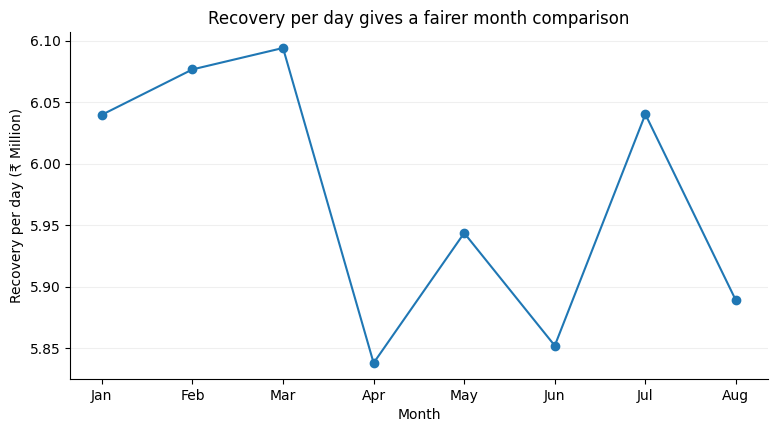

In [8]:
plt.figure(figsize=(9,4.5))
plt.plot(monthly_recovery['month_name'], monthly_recovery['recovery_per_day']/1e6, marker='o')
plt.title('Recovery per day gives a fairer month comparison')
plt.xlabel('Month')
plt.ylabel('Recovery per day (₹ Million)')
plt.grid(axis='y', alpha=0.2)
plt.show()

### Plain-English conclusion
The February → March increase is about **11.0% in the monthly total**, but only about **0.3% after adjusting for the number of days**.

So that particular 11% headline is mostly a **calendar effect**, not evidence of an 11% improvement in daily collection performance.

## 6. Build the Golden account-month dataset

For the main business KPIs, I use one row per **targeted account per month**. This gives a stable denominator and allows us to compare targeting mix, payment conversion and recovery fairly.

In [9]:
# Recovery by month and account
account_recovery = (
    recovered.groupby(['month','account_id'], as_index=False)['amount']
    .sum()
    .rename(columns={'amount':'recovered_amount'})
)

# One row per targeted account per month
golden = monthly_targets.merge(
    accounts_clean[['account_id','borrower_id','loan_type','outstanding_amount','dpd','risk_segment','status']],
    on='account_id', how='left'
)

golden = golden.merge(account_recovery, on=['month','account_id'], how='left')
golden['recovered_amount'] = golden['recovered_amount'].fillna(0)
golden['made_payment'] = golden['recovered_amount'] > 0

golden.head()

,month,account_id,borrower_id,loan_type,outstanding_amount,dpd,risk_segment,status,recovered_amount,made_payment
0,2026-04-01,ACC0028555,BRW0010875,BNPL,"527,650.91",90,MEDIUM,ACTIVE,0.00,False
1,2026-08-01,ACC0007194,BRW0007100,BNPL,"137,263.69",45,NPA,ACTIVE,0.00,False
2,2026-05-01,ACC0029550,BRW0008204,AUTO,"302,507.02",120,MEDIUM,PAID,0.00,False
3,2026-07-01,ACC0012329,BRW0010974,CONSUMER,"684,217.18",75,NPA,PAID,0.00,False
4,2026-07-01,ACC0018387,BRW0002764,CONSUMER,"174,799.69",180,HIGH,CLOSED,0.00,False


### Why this is the Golden Dataset
This is the table I would trust for the main recovery analysis because every row has a clear meaning:

> **one targeted account in one month**

From this single table we can calculate recovery per target, payer conversion, recovery as a share of outstanding balance, and segment-level performance without changing the denominator halfway through the analysis.

## 7. Independent monthly KPIs

Now I calculate several measures instead of relying on one headline percentage.

In [10]:
monthly_kpis = golden.groupby('month').agg(
    targeted_accounts=('account_id','nunique'),
    total_recovery=('recovered_amount','sum'),
    paying_accounts=('made_payment','sum'),
    targeted_outstanding=('outstanding_amount','sum')
).reset_index()

monthly_kpis['recovery_per_target'] = monthly_kpis['total_recovery'] / monthly_kpis['targeted_accounts']
monthly_kpis['payer_conversion_pct'] = monthly_kpis['paying_accounts'] / monthly_kpis['targeted_accounts'] * 100
monthly_kpis['recovery_pct_of_outstanding'] = monthly_kpis['total_recovery'] / monthly_kpis['targeted_outstanding'] * 100
monthly_kpis['month_name'] = monthly_kpis['month'].dt.strftime('%b')

monthly_kpis[['month_name','targeted_accounts','total_recovery','recovery_per_target','payer_conversion_pct','recovery_pct_of_outstanding']]

,month_name,targeted_accounts,total_recovery,recovery_per_target,payer_conversion_pct,recovery_pct_of_outstanding
0,Jan,5732,"37,196,059.79","6,489.19",8.06,1.86
1,Feb,5160,"27,945,637.33","5,415.82",6.76,1.55
2,Mar,5666,"38,435,405.07","6,783.52",8.37,1.95
3,Apr,5585,"33,069,350.75","5,921.10",7.74,1.70
4,May,5800,"34,329,594.37","5,918.90",7.79,1.69
5,Jun,5535,"32,859,753.05","5,936.72",7.80,1.70
6,Jul,5666,"37,763,870.63","6,665.00",8.51,1.85
7,Aug,1566,"1,715,710.57","1,095.60",1.53,0.31


## 8. June → July: did performance improve?

July is the latest **complete** month in the dataset, so June → July is the most useful recent comparison.

In [11]:
jun = monthly_kpis[monthly_kpis['month'].eq(pd.Timestamp('2026-06-01'))].iloc[0]
jul = monthly_kpis[monthly_kpis['month'].eq(pd.Timestamp('2026-07-01'))].iloc[0]

comparison = pd.DataFrame({
    'Metric': [
        'Targeted accounts',
        'Recovery from targeted accounts',
        'Recovery per targeted account',
        'Payer conversion',
        'Recovery % of outstanding'
    ],
    'June': [
        jun['targeted_accounts'], jun['total_recovery'], jun['recovery_per_target'],
        jun['payer_conversion_pct'], jun['recovery_pct_of_outstanding']
    ],
    'July': [
        jul['targeted_accounts'], jul['total_recovery'], jul['recovery_per_target'],
        jul['payer_conversion_pct'], jul['recovery_pct_of_outstanding']
    ]
})
comparison['Change %'] = (comparison['July'] / comparison['June'] - 1) * 100
comparison

,Metric,June,July,Change %
0,Targeted accounts,"5,535.00","5,666.00",2.37
1,Recovery from targeted accounts,"32,859,753.05","37,763,870.63",14.92
2,Recovery per targeted account,"5,936.72","6,665.00",12.27
3,Payer conversion,7.80,8.51,8.99
4,Recovery % of outstanding,1.70,1.85,9.18


### What changed from June to July?
July did look better on the targeted portfolio:

- more accounts were targeted,
- more targeted accounts paid,
- recovery per targeted account improved,
- recovery as a share of targeted outstanding improved.

But this still does **not** prove the collection process itself became 11% better. The next question is whether July simply targeted a better set of accounts.

## 9. Same-account test: remove most of the portfolio-mix effect

A simple way to test mix is to compare only accounts that were targeted in **both June and July**. These are much more comparable than two completely different monthly populations.

In [12]:
june_accounts = set(monthly_targets.loc[monthly_targets['month'].eq(pd.Timestamp('2026-06-01')), 'account_id'])
july_accounts = set(monthly_targets.loc[monthly_targets['month'].eq(pd.Timestamp('2026-07-01')), 'account_id'])

same_accounts = june_accounts.intersection(july_accounts)

same_panel = golden[
    golden['account_id'].isin(same_accounts) &
    golden['month'].isin([pd.Timestamp('2026-06-01'), pd.Timestamp('2026-07-01')])
]

same_month = same_panel.groupby('month').agg(
    accounts=('account_id','nunique'),
    recovery=('recovered_amount','sum')
).reset_index()
same_month['recovery_per_account'] = same_month['recovery'] / same_month['accounts']
same_month['month_name'] = same_month['month'].dt.strftime('%b')

same_month

,month,accounts,recovery,recovery_per_account,month_name
0,2026-06-01,1050,"6,157,210.76","5,864.01",Jun
1,2026-07-01,1050,"6,239,332.53","5,942.22",Jul


In [13]:
same_change = (same_month.loc[same_month['month_name']=='Jul','recovery_per_account'].iloc[0] /
               same_month.loc[same_month['month_name']=='Jun','recovery_per_account'].iloc[0] - 1) * 100

print(f'Accounts targeted in both months: {len(same_accounts):,}')
print(f'Change in recovery per account for the SAME accounts: {same_change:.2f}%')

Accounts targeted in both months: 1,050
Change in recovery per account for the SAME accounts: 1.33%


### This is one of the strongest findings
The overall targeted population shows a much larger improvement than the **same-account cohort**.

That suggests a meaningful part of July's apparent improvement came from **which accounts were selected**, not just from agents or channels suddenly becoming more productive.

This is **strong evidence of a portfolio/targeting mix effect**. It is not a perfect causal test, but it is much more convincing than comparing two raw monthly totals.

## 10. Were July's newly targeted accounts better?

To make the mix effect easier to see, compare:

- accounts targeted in July but not June
- accounts targeted in June but not July
- accounts targeted in both months

In [14]:
new_in_july = july_accounts - june_accounts
june_only = june_accounts - july_accounts

july_new_data = golden[
    golden['month'].eq(pd.Timestamp('2026-07-01')) & golden['account_id'].isin(new_in_july)
]
june_only_data = golden[
    golden['month'].eq(pd.Timestamp('2026-06-01')) & golden['account_id'].isin(june_only)
]
same_june_data = golden[
    golden['month'].eq(pd.Timestamp('2026-06-01')) & golden['account_id'].isin(same_accounts)
]

def group_summary(df, label):
    return {
        'Group': label,
        'Accounts': df['account_id'].nunique(),
        'Recovery / account': df['recovered_amount'].sum() / df['account_id'].nunique(),
        'Payer conversion %': df['made_payment'].mean() * 100
    }

mix_table = pd.DataFrame([
    group_summary(june_only_data, 'June-only targets'),
    group_summary(same_june_data, 'Targeted in both months'),
    group_summary(july_new_data, 'New July targets')
])
mix_table

,Group,Accounts,Recovery / account,Payer conversion %
0,June-only targets,4485,"5,953.74",7.85
1,Targeted in both months,1050,"5,864.01",7.62
2,New July targets,4616,"6,829.41",8.64


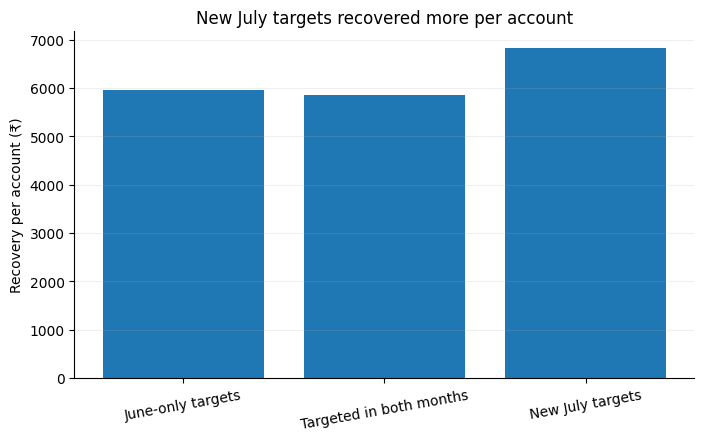

In [15]:
plt.figure(figsize=(8,4.5))
plt.bar(mix_table['Group'], mix_table['Recovery / account'])
plt.title('New July targets recovered more per account')
plt.ylabel('Recovery per account (₹)')
plt.xticks(rotation=10)
plt.grid(axis='y', alpha=0.2)
plt.show()

### Business meaning
The new July targets perform better than the June-only targets on recovery per account. This supports the idea that **better account selection contributed to July's improvement**.

This is why I would not describe the result as “operations improved by 11%.” A safer statement is:

> **July recovery improved, but a large part of the improvement appears to come from targeting/portfolio mix rather than a proven 11% operational uplift.**

## 11. Did calling performance also improve?

If better calling infrastructure or agent execution caused the recovery lift, we would expect contact performance to improve as well.

In [16]:
call_month = calls.groupby('month').agg(
    calls=('call_id','nunique'),
    answered=('is_answered','sum')
).reset_index()
call_month['contact_rate_pct'] = call_month['answered'] / call_month['calls'] * 100
call_month['month_name'] = call_month['month'].dt.strftime('%b')

call_month[['month_name','calls','answered','contact_rate_pct']]

,month_name,calls,answered,contact_rate_pct
0,Dec,1,0,0.00
1,Jan,12683,2545,20.07
2,Feb,11570,2282,19.72
3,Mar,12845,2570,20.01
4,Apr,12241,2366,19.33
5,May,12746,2594,20.35
6,Jun,12128,2476,20.42
7,Jul,12578,2433,19.34
8,Aug,3210,630,19.63


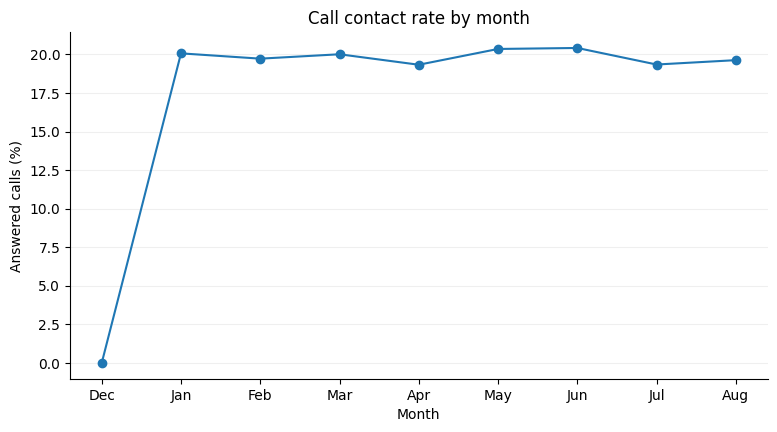

In [17]:
plt.figure(figsize=(9,4.5))
plt.plot(call_month['month_name'], call_month['contact_rate_pct'], marker='o')
plt.title('Call contact rate by month')
plt.xlabel('Month')
plt.ylabel('Answered calls (%)')
plt.grid(axis='y', alpha=0.2)
plt.show()

### Takeaway
June → July recovery improved, but the call answer rate did **not** improve. That makes it harder to argue that telephony alone explains the recovery lift.

This again points us toward **selection/targeting** as a more plausible contributor.

## 12. Simple driver checks

I now look at a few transparent cuts of the Golden Dataset. The goal is not to find a “winner” by chance, but to see whether performance differences are large enough to matter.

In [18]:
# Use complete months only (Jan-Jul)
complete = golden[golden['month'] < pd.Timestamp('2026-08-01')].copy()

risk_view = complete.groupby('risk_segment').agg(
    targeted_accounts=('account_id','size'),
    recovery=('recovered_amount','sum'),
    payers=('made_payment','sum')
)
risk_view['recovery_per_target'] = risk_view['recovery'] / risk_view['targeted_accounts']
risk_view['payer_conversion_pct'] = risk_view['payers'] / risk_view['targeted_accounts'] * 100
risk_view.sort_values('recovery_per_target', ascending=False)

,targeted_accounts,recovery,payers,recovery_per_target,payer_conversion_pct
risk_segment,,,,,
LOW,9913,"63,793,260.18",808,"6,435.31",8.15
HIGH,9759,"61,902,874.89",794,"6,343.16",8.14
MEDIUM,9851,"60,378,088.64",763,"6,129.13",7.75
NPA,9621,"55,525,447.28",718,"5,771.28",7.46


In [19]:
dpd_bins = [-1, 0, 30, 60, 90, np.inf]
dpd_labels = ['0', '1-30', '31-60', '61-90', '90+']
complete['dpd_bucket'] = pd.cut(complete['dpd'], bins=dpd_bins, labels=dpd_labels)

dpd_view = complete.groupby('dpd_bucket', observed=False).agg(
    targets=('account_id','size'),
    recovery=('recovered_amount','sum'),
    payers=('made_payment','sum')
)
dpd_view['recovery_per_target'] = dpd_view['recovery'] / dpd_view['targets']
dpd_view['payer_conversion_pct'] = dpd_view['payers'] / dpd_view['targets'] * 100
dpd_view

,targets,recovery,payers,recovery_per_target,payer_conversion_pct
dpd_bucket,,,,,
0,3472,"20,406,663.66",261,"5,877.50",7.52
1-30,14190,"84,641,633.64",1082,"5,964.88",7.63
31-60,7303,"48,006,187.19",613,"6,573.49",8.39
61-90,7081,"45,357,284.13",561,"6,405.49",7.92
90+,7098,"43,187,902.37",566,"6,084.52",7.97


### How to read these tables
Small differences between segments are useful for targeting ideas, but they are **correlations**, not proof that changing a segment causes higher recovery.

For an interview, say this clearly: *“I use these cuts to find where to test next. I would not call them causal without a controlled experiment.”*

## 13. Final answer to the 11% question

### What happened?
- A raw February → March total shows about **+11%**.
- After adjusting for the extra days in March, the increase is only about **+0.3% per day**.
- The latest complete-month comparison, June → July, does show a genuine improvement on several targeted-portfolio metrics.

### Why did July look better?
- The overall targeted population improved strongly.
- But the **same accounts** targeted in both June and July improved only slightly.
- Newly targeted July accounts recovered more per account than June-only targets.
- Call answer rate did not improve at the same time.

### My conclusion
> **The exact “11% operational improvement” claim is not supported. Recovery did improve in July, but the evidence suggests that targeting/portfolio mix explains a meaningful part of that improvement.**

This wording is more accurate than saying either “11% is completely fake” or “operations definitely improved by 11%.”

## 14. Where should the ₹10 Cr go?

### Recommendation: Better borrower targeting

Why this is the best first choice from the available data:

1. The same-account test shows only a small improvement, while the full targeted population improves much more.
2. New July targets recover more per account than the accounts that dropped out after June.
3. Contact rate does not improve alongside recovery, so telephony is not the strongest explanation.
4. Better targeting can improve which accounts receive expensive human, digital or field effort before adding more capacity.

### Important limitation
The dataset does not contain reliable full cost data or a randomized experiment. Therefore, I would **not present a precise ROI as a fact**.

A sensible business plan is to allocate the ₹10 Cr to a targeting program in stages and keep a randomized holdout group. Measure incremental recovery per targeted account and recovery as a percentage of outstanding balance before scaling the full investment.

## 15. Confidence labels

| Finding | Confidence |
|---|---|
| 500 duplicate payment IDs exist | **Fact** |
| Feb → Mar raw recovery rises ~11% | **Fact** |
| Feb → Mar recovery/day is almost flat | **Fact** |
| June → July targeted recovery improves | **Fact** |
| Same-account June → July improvement is much smaller | **Fact** |
| Targeting mix contributed to July's improvement | **Strong evidence** |
| Better targeting caused the full July uplift | **Hypothesis** |
| Better borrower targeting is the best ₹10 Cr option | **Recommendation based on current evidence** |

This distinction keeps the analysis honest and makes it easier for leadership to see what is known versus what still needs testing.